In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Загрузим полный набор данных

In [2]:
train_part1 = pd.read_parquet("../ClearData/train_full.parquet")
train_part1.shape

(85677840, 14)

In [3]:
train_part1.info()

<class 'pandas.DataFrame'>
RangeIndex: 85677840 entries, 0 to 85677839
Data columns (total 14 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   event_type_nm               int16  
 1   event_desc                  int32  
 2   channel_indicator_type      int16  
 3   channel_indicator_sub_type  int16  
 4   operaton_amt                float64
 5   currency_iso_cd             int16  
 6   mcc_code                    int16  
 7   pos_cd                      int16  
 8   developer_tools             int32  
 9   phone_voip_call_state       int32  
 10  web_rdp_connection          int16  
 11  compromised                 int16  
 12  Hour                        int16  
 13  target                      int16  
dtypes: float64(1), int16(10), int32(3)
memory usage: 3.2 GB


In [4]:
train_part1["target"].value_counts()

target
0    85626402
1       51438
Name: count, dtype: int64

In [5]:
pos_class = train_part1.loc[train_part1["target"] == 1]
pos_class.shape

(51438, 14)

In [6]:
train_part1 = train_part1.loc[train_part1["target"] != 1]
train_part1.shape

(85626402, 14)

In [7]:
neg_class = 15_000_000
train_part1 = train_part1.sample(n=neg_class)
train_part1 = pd.concat([train_part1, pos_class])
train_part1 = train_part1.sample(frac=1).reset_index(drop=True)
train_part1.shape

(15051438, 14)

In [8]:
train_part1.head()

,event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,pos_cd,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,Hour,target
0,14,75,0,5,88652.0,0,4,-1,-1,-1,-1,-1,11,0
1,7,56,4,15,-1.0,-1,-1,-1,-1,-1,-1,0,14,0
2,14,75,0,5,67079.0,0,4,-1,-1,-1,-1,-1,12,0
3,14,75,0,5,343441.0,0,4,-1,-1,-1,-1,-1,12,0
4,14,63,4,15,17647.0,0,-1,-1,-1,-1,-1,0,18,0


In [9]:
x = train_part1.drop(columns="target")
y = train_part1["target"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y)   

In [11]:
del train_part1, x, y
gc.collect()

0

In [12]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

Попробуем настроить веса меток самостоятельно

In [13]:
weights = 100
CatBoost = CatBoostClassifier(iterations=100, depth=5, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9539829122267685
Precision: 0.03085128005008008
Recall: 0.40985872899295805
F1-score: 0.05738315976343888
PR-AUC: 0.04091297289580196

Test metrics:
Accuracy: 0.9538276736312273
Precision: 0.030469297221573665
Recall: 0.4059097978227061
F1-score: 0.05668367900966446
PR-AUC: 0.039690445166319324

Confusion matrix


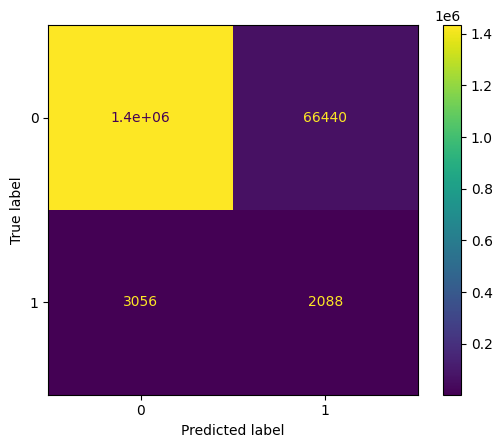

In [14]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [15]:
weights = 100
CatBoost = CatBoostClassifier(iterations=100, depth=6, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9546623600521293
Precision: 0.03156588778956295
Recall: 0.41329329934764764
F1-score: 0.058652132129002194
PR-AUC: 0.043536049292688825

Test metrics:
Accuracy: 0.9544641575822645
Precision: 0.031040094688563398
Recall: 0.4078538102643857
F1-score: 0.05768966370610718
PR-AUC: 0.042032866222975675

Confusion matrix


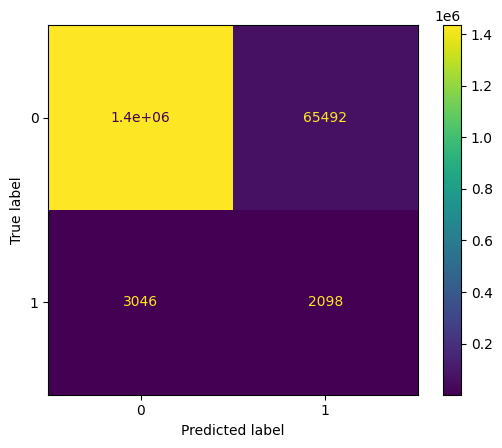

In [16]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [17]:
weights = 100
CatBoost = CatBoostClassifier(iterations=100, depth=7, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9547818023143452
Precision: 0.032020416900141985
Recall: 0.4184559554153886
F1-score: 0.059488732240823114
PR-AUC: 0.0446251572291559

Test metrics:
Accuracy: 0.9545917201277752
Precision: 0.031184167581520934
Recall: 0.40863141524105756
F1-score: 0.057946243969676084
PR-AUC: 0.04278435097117024

Confusion matrix


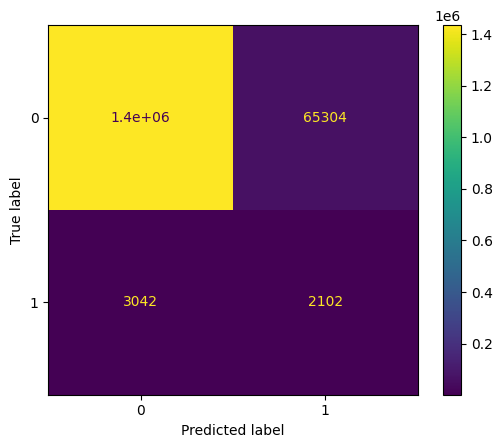

In [18]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [19]:
weights = 200
CatBoost = CatBoostClassifier(iterations=100, depth=5, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9145947223646556
Precision: 0.019709273512441977
Recall: 0.492245215362682
F1-score: 0.037901007982529746
PR-AUC: 0.03935888258399102

Test metrics:
Accuracy: 0.9143683262199497
Precision: 0.019560186982652855
Recall: 0.48969673405909797
F1-score: 0.03761778892821409
PR-AUC: 0.03880616903610086

Confusion matrix


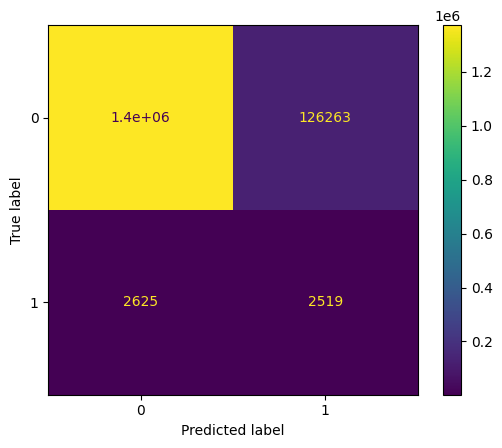

In [20]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [21]:
weights = 200
CatBoost = CatBoostClassifier(iterations=100, depth=6, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9150675454113132
Precision: 0.01994431798223114
Recall: 0.4954853760746533
F1-score: 0.03834516330713242
PR-AUC: 0.04157099245001681

Test metrics:
Accuracy: 0.9146706228772795
Precision: 0.019637026704797823
Recall: 0.48989113530326595
F1-score: 0.0377604459328853
PR-AUC: 0.040431115837802914

Confusion matrix


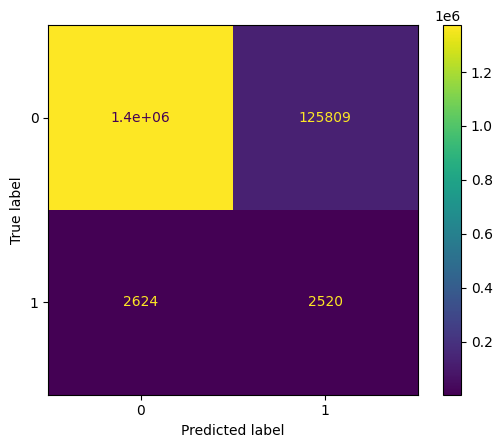

In [22]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [31]:
weights = 200
CatBoost = CatBoostClassifier(iterations=100, depth=7, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9170886886110695
Precision: 0.020429830741564466
Recall: 0.4954637750032402
F1-score: 0.039241583726470575
PR-AUC: 0.043093591830062436

Test metrics:
Accuracy: 0.9167933433611668
Precision: 0.01995427146123467
Recall: 0.48522550544323484
F1-score: 0.03833218152499424
PR-AUC: 0.042113718221575905

Confusion matrix


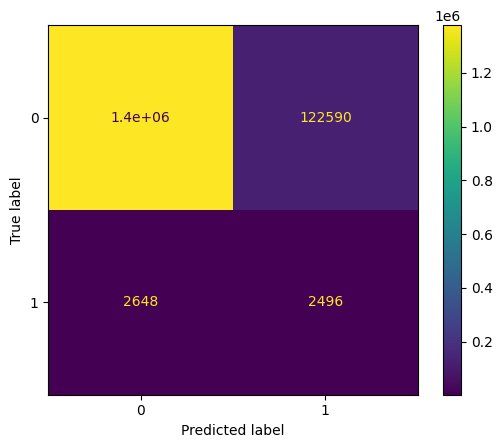

In [32]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [25]:
weights = 300
CatBoost = CatBoostClassifier(iterations=100, depth=5, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.7717104766809284
Precision: 0.009708665982295849
Recall: 0.6514883138203655
F1-score: 0.019132218154229403
PR-AUC: 0.03801636487115174

Test metrics:
Accuracy: 0.771510898624982
Precision: 0.009699913450488758
Recall: 0.651438569206843
F1-score: 0.01911520174780597
PR-AUC: 0.0373657272160382

Confusion matrix


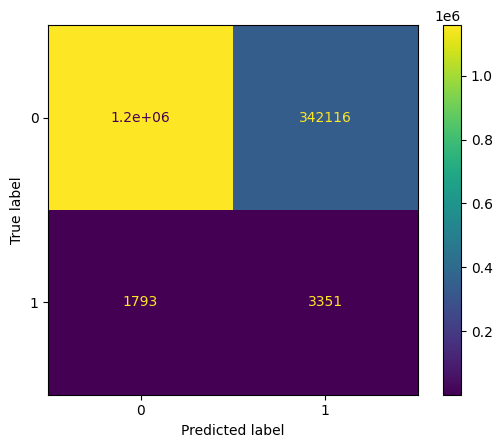

In [26]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [27]:
weights = 300
CatBoost = CatBoostClassifier(iterations=100, depth=6, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.7761006811161784
Precision: 0.009882071539502687
Recall: 0.6504082602497084
F1-score: 0.019468347931900224
PR-AUC: 0.03948783297996434

Test metrics:
Accuracy: 0.77602010173113
Precision: 0.00983640444129459
Recall: 0.6475505443234837
F1-score: 0.019378446931794382
PR-AUC: 0.03864953079469637

Confusion matrix


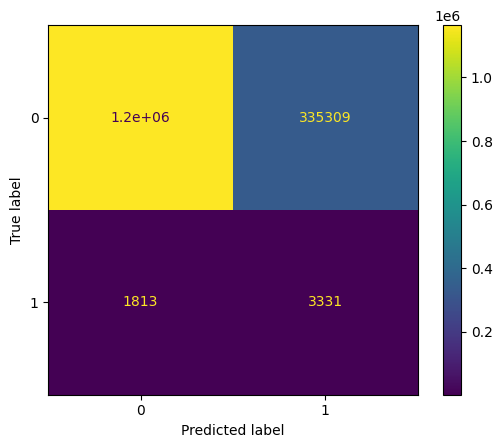

In [28]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [29]:
weights = 300
CatBoost = CatBoostClassifier(iterations=100, depth=7, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.768941748938861
Precision: 0.00974005016927121
Recall: 0.6616840195273685
F1-score: 0.019197511192333278
PR-AUC: 0.041553808156487314

Test metrics:
Accuracy: 0.7687138240593591
Precision: 0.00965324381589068
Recall: 0.656298600311042
F1-score: 0.019026632212832267
PR-AUC: 0.0393616840616226

Confusion matrix


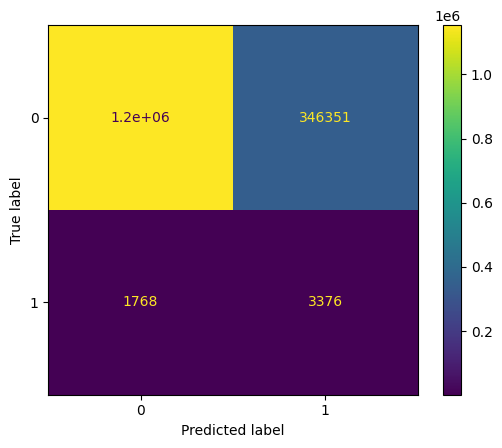

In [30]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

Из последних показателей могу сделать вывод, что увеличение числа деревьев в ансамбле (после некоторого значения деревьев) сильного эффекта уже не дает, т.е. есть конкретный предел точночти, к которому при постоянном увеличении кол-ва деревьев модель стремится  

### Проверим лучшие модели

In [33]:
weights = 100
CatBoost = CatBoostClassifier(iterations=1000, depth=5, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.955547325342267
Precision: 0.03435023061548282
Recall: 0.44288676718365233
F1-score: 0.063755587515062
PR-AUC: 0.052525710817558434

Test metrics:
Accuracy: 0.9551159224632327
Precision: 0.031412826403591755
Recall: 0.40668740279937793
F1-score: 0.058320904364310505
PR-AUC: 0.04528284162868382

Confusion matrix


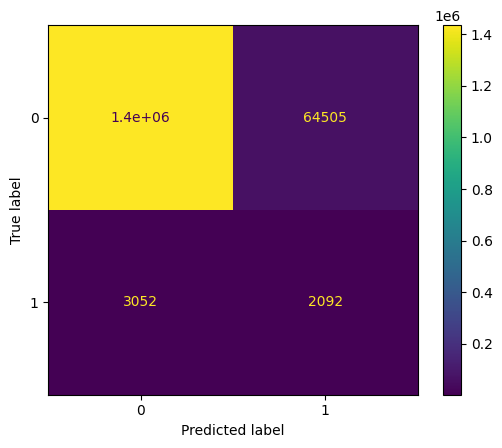

In [34]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [35]:
weights = 100
CatBoost = CatBoostClassifier(iterations=1000, depth=6, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9573540187449054
Precision: 0.03664297859353882
Recall: 0.45388171253294163
F1-score: 0.06781137902823699
PR-AUC: 0.05696173187540247

Test metrics:
Accuracy: 0.956861934804909
Precision: 0.03198634748164269
Recall: 0.39716174183514774
F1-score: 0.059204520756357314
PR-AUC: 0.044217222677330394

Confusion matrix


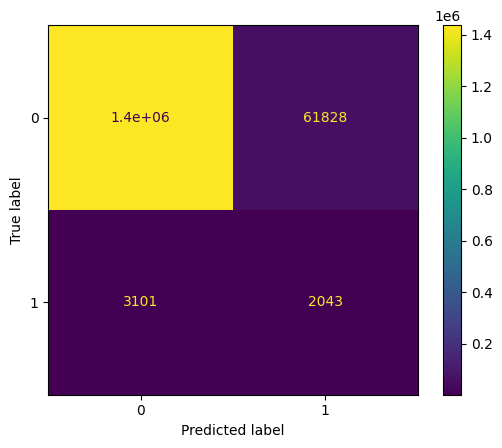

In [36]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [37]:
weights = 100
CatBoost = CatBoostClassifier(iterations=1000, depth=7, scale_pos_weight=weights, verbose=False)

Train metrics:
Accuracy: 0.9569795251749298
Precision: 0.037563873583747666
Recall: 0.47066574502095304
F1-score: 0.06957496335891025
PR-AUC: 0.061564758713054536

Test metrics:
Accuracy: 0.9563696231058291
Precision: 0.03160501470360625
Recall: 0.39696734059097977
F1-score: 0.05854861369957278
PR-AUC: 0.042458339124141084

Confusion matrix


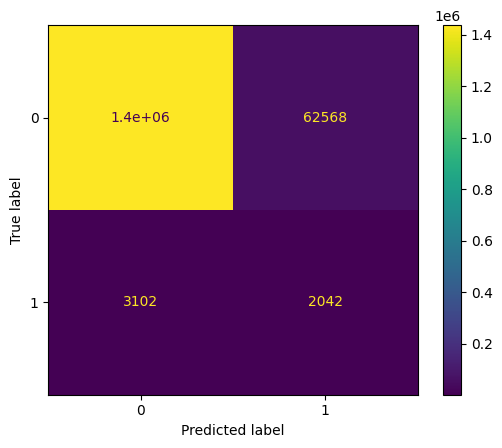

In [38]:
train_models(CatBoost, X_train, X_test, y_train, y_test)